In [1]:
# Behzad Ghabaei
# CS 82A - Data Science
# module5_lab3.ipynb
# custdata.tsv
# Text Book Problem 5.5
# Age, income, vehicles: what correlates?
# Instructor Seno
# 10/1/2026

In [2]:
import pandas as pd
df = pd.read_csv("custdata.tsv", sep="\t")

#### Lets import the dataset and run four commands first.

In [3]:
df.describe()

,custid,income,num.vehicles,age
count,1.000000e+03,1000.000000,944.000000,1000.000000
mean,6.984997e+05,53504.771000,1.916314,51.699815
std,4.135083e+05,65478.065729,1.101618,18.863433
min,2.068000e+03,-8700.000000,0.000000,0.000000
25%,3.456668e+05,14600.000000,1.000000,38.000000
50%,6.934030e+05,35000.000000,2.000000,50.000000
75%,1.044606e+06,67000.000000,2.000000,64.000000
max,1.414286e+06,615000.000000,6.000000,146.680197


#### Age min is at 0 which doesn't exist, age max at 146, which is hard to believe.
#### Num.vehicles min and max look true.
#### Income max is ok, but min is a negative number, looking like an impossible number.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   custid        1000 non-null   int64  
 1   sex           1000 non-null   str    
 2   is.employed   672 non-null    object 
 3   income        1000 non-null   int64  
 4   marital.stat  1000 non-null   str    
 5   health.ins    1000 non-null   bool   
 6   housing.type  944 non-null    str    
 7   recent.move   944 non-null    object 
 8   num.vehicles  944 non-null    float64
 9   age           1000 non-null   float64
 10  state.of.res  1000 non-null   str    
dtypes: bool(1), float64(2), int64(2), object(2), str(4)
memory usage: 79.2+ KB


#### NaN empty data points listed in num.vehicles, to be dropped. 1000 - 944 = 56 (a large amount of data)

In [5]:
df.head()

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
0,2068,F,NaN,11300,Married,True,Homeowner free and clear,False,2.0,49.0,Michigan
1,2073,F,NaN,0,Married,True,Rented,True,3.0,40.0,Florida
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida


In [6]:
df.shape

(1000, 11)

#### Lets also take a look at the heapmap for correlations before cleaning the data.

<Axes: >

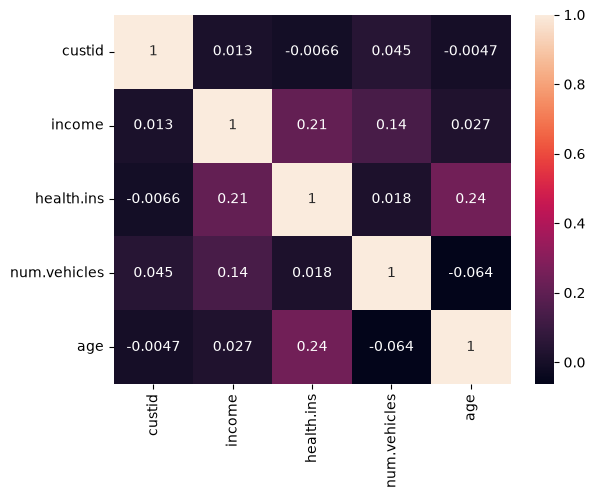

In [7]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True), annot=True)

#### No powerful linear relationships or correlations are present.  We will proceed by dropping null values.

In [8]:
df.dropna(inplace=True)

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 664 entries, 2 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   custid        664 non-null    int64  
 1   sex           664 non-null    str    
 2   is.employed   664 non-null    object 
 3   income        664 non-null    int64  
 4   marital.stat  664 non-null    str    
 5   health.ins    664 non-null    bool   
 6   housing.type  664 non-null    str    
 7   recent.move   664 non-null    object 
 8   num.vehicles  664 non-null    float64
 9   age           664 non-null    float64
 10  state.of.res  664 non-null    str    
dtypes: bool(1), float64(2), int64(2), object(2), str(4)
memory usage: 57.7+ KB


#### The new count sum of our dataset is at 664.  Next, We would like to address the outliers and check for numbers that skew the dataset. Especially from age, num.vehicles, and income. 

#### Below, we build a list of ages that are 0.

In [10]:
df[df["age"] <= 0 ]

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
868,1229417,F,True,48000,Married,True,Homeowner with mortgage/loan,False,3.0,0.0,Washington
965,1375846,F,True,113950,Divorced/Separated,True,Rented,False,2.0,0.0,Louisiana


#### Below, we have a list of ages that are more than 125 years old.

In [11]:
df[df["age"] > 125 ]

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
212,287882,M,True,60000,Married,True,Rented,True,2.0,137.700030,Florida
286,397230,F,True,31200,Married,True,Rented,False,2.0,136.052160,Texas
593,843811,F,True,40000,Never Married,True,Homeowner with mortgage/loan,False,1.0,146.680197,Indiana
752,1047534,M,True,200000,Married,True,Homeowner with mortgage/loan,False,4.0,130.401605,Washington
926,1303929,F,False,43400,Never Married,True,Rented,False,1.0,126.737284,West Virginia


#### Below we have a list with a negative income figure.

In [12]:
df[df["income"] < 0 ]

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
691,971703,M,False,-8700,Married,True,Homeowner with mortgage/loan,False,3.0,60.0,Oklahoma


#### There are no negative vehicles.

In [13]:
df[df["num.vehicles"] < 0 ]

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res


#### Lets impute rows with age listed as 0 with the median, next lets drop the rows with the age above 125 years old. Finally lets make the income a positive number for any negative income numbers, ( or negative num.vehicles which were not found). 

In [14]:
df.loc[df["age"] <= 0, "age"] = df["age"].median()
print("Imputed those zeros/negatives with the median at:", df["age"].median())

Imputed those zeros/negatives with the median at: 46.0


In [15]:
df = df[df["age"] <= 125]
print("Dropped those rows with outlier ages")

Dropped those rows with outlier ages


In [16]:
df["income"] = df["income"].abs()
print("Made any negative income numbers positive")

Made any negative income numbers positive


#### Now a quick glance at the dataset, looking for "anomalies"

In [17]:
df.describe()

,custid,income,num.vehicles,age
count,6.590000e+02,659.000000,659.000000,659.000000
mean,7.044867e+05,66781.071320,2.031866,45.796427
std,4.065869e+05,70641.760578,1.088996,13.095060
min,2.848000e+03,0.000000,0.000000,19.000000
25%,3.567255e+05,25000.000000,1.000000,36.000000
50%,7.165180e+05,45000.000000,2.000000,46.000000
75%,1.041560e+06,82500.000000,3.000000,55.000000
max,1.414286e+06,615000.000000,6.000000,124.845087


#### The average age looks close to the median.  There are no negative ages. The min is at 19 years old, legal age to drive, and the max age is 124 years old, the rate at 124.84 is old but they can own a vehicle with a hired driver.  It is possible to have zero income, or zero number of vehicles.

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 659 entries, 2 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   custid        659 non-null    int64  
 1   sex           659 non-null    str    
 2   is.employed   659 non-null    object 
 3   income        659 non-null    int64  
 4   marital.stat  659 non-null    str    
 5   health.ins    659 non-null    bool   
 6   housing.type  659 non-null    str    
 7   recent.move   659 non-null    object 
 8   num.vehicles  659 non-null    float64
 9   age           659 non-null    float64
 10  state.of.res  659 non-null    str    
dtypes: bool(1), float64(2), int64(2), object(2), str(4)
memory usage: 57.3+ KB


#### The final count sum of data points is at 659, in this cleaned dataset.

In [19]:
df.shape

(659, 11)

In [20]:
df.head()

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida
5,8322,F,True,180000,Never Married,True,Homeowner with mortgage/loan,False,1.0,40.0,New York
6,8521,M,True,120000,Never Married,True,Homeowner free and clear,True,1.0,39.0,Idaho


#### Next a seaborn heatmap will display any correlations that may exist. We want a number preferable from +.5 to +1 or -.5 to -1. 

<Axes: >

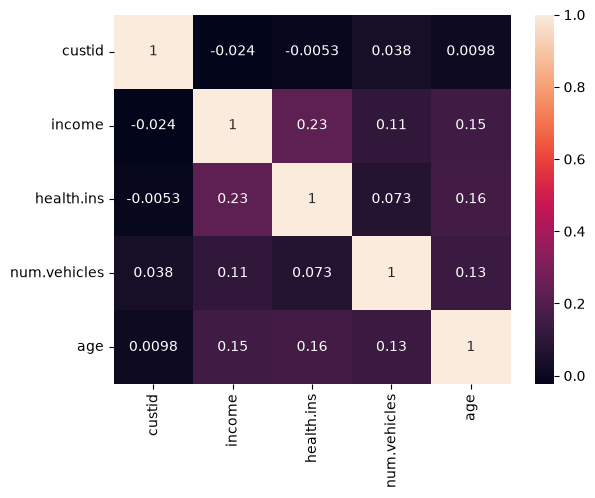

In [21]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [22]:
print(df["age"].corr(df["income"]))
print(df["age"].corr(df["num.vehicles"]))
print(df["income"].corr(df["num.vehicles"]))

0.14851820738846347
0.13216118755718342
0.10870287853742812


#### After looking at the cleaned data heatmap of Pearson's r correlations, there are no relationships found to be strong enough.  The correlation between age, income, and number of vehicles, is not present.  
#### "Age" vs. "Income" at **0.15** is a weak positive correlation.
#### "Age" vs. "Number Vehicles" is **0.13** another weak positive relationship. 
#### "Income" vs. "Number Vehicles" is at **0.11** a weak positive relationship.
#### "Income" vs. "Health Insurance" has a slightly stronger linear relationship at 0.23.
#### Although the datset was enormous and the variables used often could return strong economic relationships, the dataset does not provide a strong enough correlation between these three variables. The ages did not show younger participants as being any wealthier or poorer that older, when looking at age vs. income.
## Cleaning Log
#### Those ages which were at 0 were imputed with the median. Ages above 124 years old were not trusted as good data points and dropped.
#### Negative income was made into a positive number due to possible data entry error, at -87000.
#### Any values with NaN were dropped from the dataset, to avoid noise and skew.
#### The count of data points was at 659. The final average of age was around 46 years old, very close to the median.

## Behzad Ghabaei - End Of Lab